# Exercício 1 — Representação clássica versus abordagem pela complexidade

Este notebook explora a diferença entre a **abordagem clássica** (equações diferenciais) e a **abordagem pela complexidade** (simulação baseada em agentes) para modelar um mesmo sistema dinâmico: o modelo **presa-predador** (Lotka-Volterra).


## 1. Contexto

O modelo presa-predador descreve a interação entre duas populações:
- **Presas** (coelhos): reproduzem-se rapidamente e servem de alimento
- **Predadores** (lobos): caçam as presas para sobreviver

Na **abordagem clássica**, esse sistema é representado por um par de equações diferenciais ordinárias (EDO). Na **abordagem pela complexidade**, cada animal é um agente individual que se move, reproduz e morre segundo regras locais.

Vamos gerar ambos os modelos com auxílio da IA e compará-los.


## 2. Célula auxiliar — imports e path discovery

Execute a célula abaixo para carregar as bibliotecas e configurar os diretórios de saída.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import os
_repo = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(_repo, 'setup.sh')):
        break
    _repo = os.path.dirname(_repo)
PASTA_MOODLE = os.path.join(_repo, 'work', 'tarefas_moodle')
os.makedirs(PASTA_MOODLE, exist_ok=True)
PASTA_AULA = os.path.join(PASTA_MOODLE, 'tarefa_aula06')
os.makedirs(PASTA_AULA, exist_ok=True)

print("Diretorio de saida:", PASTA_AULA)


Diretorio de saida: /l/disk0/viniciusd/Projetos/simserv_jupyter_env/work/tarefas_moodle/tarefa_aula06


## 3. Abordagem clássica — EDO

A IA vai gerar o código para resolver numericamente as equações de Lotka-Volterra:

\[
\frac{dx}{dt} = \alpha x - \beta xy \qquad
\frac{dy}{dt} = \delta xy - \gamma y
\]

Onde:
- \(x\) = população de presas, \(y\) = população de predadores
- \(\alpha\) = taxa de natalidade das presas
- \(\beta\) = taxa de predação
- \(\delta\) = taxa de conversão de presas em predadores
- \(\gamma\) = taxa de mortalidade dos predadores


### 3.1. IA gera o código da abordagem clássica

Execute a célula abaixo para que a IA produza o código Python que resolve numericamente as equações de Lotka-Volterra e plota o resultado.


In [12]:
from dotenv import load_dotenv
load_dotenv()
import os, json
from urllib.request import Request, urlopen

MODELO = os.getenv('OLLAMA_MODEL', 'ministral-3:3b')
BASE_URL = os.getenv('OLLAMA_BASE_URL', 'https://api.ollama.com').rstrip('/')
API_KEY = os.getenv('OLLAMA_API_KEY')

prompt_classica = '''Voce e um assistente de um curso de sistemas de muitos agentes.
Gere APENAS codigo Python (sem explicacoes) que:

1. Resolve numericamente as equacoes de Lotka-Volterra (presa-predador) usando scipy.integrate.solve_ivp
2. Parametros: alpha=0.1, beta=0.02, delta=0.02, gamma=0.1
3. Condicoes iniciais: x0=40 presas, y0=9 predadores
4. Tempo: t de 0 a 200, 1000 pontos
5. Plota duas figuras lado a lado (1x2):
   - Grafico esquerdo: populacao x tempo (presas em verde, predadores em vermelho)
   - Grafico direito: retrato de fase (presas vs predadores)
6. Salva a figura em: f"{os.environ.get('PASTA_AULA_SAVE', '.')}/aula_06_exercicio_01_classica.png" com dpi=150
7. Exibe a figura com plt.show()
8. Nao use parametros desnecessarios, nao use widgets, nao use ipywidgets
9. Assuma que numpy, matplotlib.pyplot, scipy.integrate.solve_ivp ja estao importados
10. Use PASTA_AULA_SAVE = os.environ.get('PASTA_AULA_SAVE', '.') como prefixo para salvar

Retorne APENAS o codigo, sem marcacao ```python ou ```'''

headers = {
    'Content-Type': 'application/json',
    'User-Agent': 'Mozilla/5.0',
    'Accept': 'application/json',
}
if API_KEY:
    headers['Authorization'] = f'Bearer {API_KEY}'

payload = {
    'model': MODELO,
    'messages': [{'role': 'user', 'content': prompt_classica}],
    'stream': False,
    'options': {'temperature': 0.2, 'top_p': 0.9, 'num_predict': 1200},
}

try:
    req = Request(BASE_URL + '/api/chat', data=json.dumps(payload).encode('utf-8'), headers=headers, method='POST')
    with urlopen(req, timeout=60) as resp:
        dados = json.loads(resp.read().decode('utf-8'))
    codigo_classica = dados.get('message', {}).get('content', '').strip()
    if codigo_classica:
        print('Codigo da abordagem classica gerado com sucesso!')
    else:
        codigo_classica = '# IA retornou codigo vazio.'
        print('IA retornou codigo vazio.')
except Exception as e:
    codigo_classica = f'# Erro ao consultar IA: {type(e).__name__}: {e}'
    print(f'Erro ao consultar IA: {type(e).__name__}: {e}')

print()
print("Codigo gerado:")
print(codigo_classica)


Codigo da abordagem classica gerado com sucesso!

Codigo gerado:
```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import os

def lotka_volterra(t, state, alpha, beta, delta, gamma):
    x, y = state
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

alpha, beta, delta, gamma = 0.1, 0.02, 0.02, 0.1
x0, y0 = 40, 9
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

sol = solve_ivp(lotka_volterra, t_span, [x0, y0], args=(alpha, beta, delta, gamma), t_eval=t_eval)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0], 'g-', label='Presas')
plt.plot(sol.t, sol.y[1], 'r-', label='Predadores')
plt.xlabel('Tempo')
plt.ylabel('População')
plt.title('População ao longo do tempo')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(sol.y[0], sol.y[1], 'b-')
plt.xlabel('Presas')
plt.ylabel('Predadores')
plt.title('Retrato de Fase')
plt.grid(True)

PastaSalva 

### 3.2. Executar o código clássico

Execute abaixo o código gerado pela IA. Verifique se há erros e ajuste se necessário.


In [13]:
# Codigo gerado pela IA para a abordagem classica (EDO)
import os
os.environ['PASTA_AULA_SAVE'] = PASTA_AULA

# === CODIGO GERADO PELA IA ===
# (substitua pelo conteudo da celula anterior se necessario)



### 3.3. Código curado (fallback)

Se a IA não gerou código válido, use a versão abaixo.


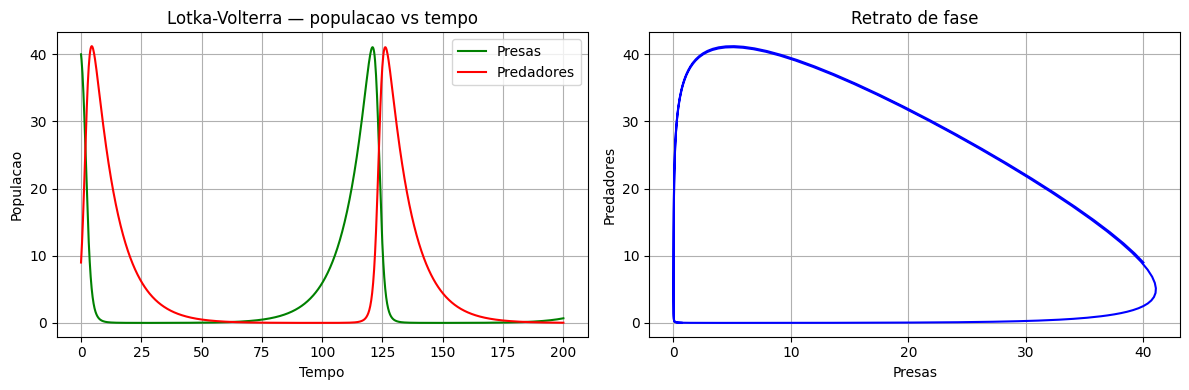

Figura salva como aula_06_exercicio_01_classica.png


In [14]:
# Versao alternativa da abordagem classica (fallback)
os.environ['PASTA_AULA_SAVE'] = PASTA_AULA

alpha, beta, delta, gamma = 0.1, 0.02, 0.02, 0.1

def lotka_volterra(t, z):
    x, y = z
    dx = alpha * x - beta * x * y
    dy = delta * x * y - gamma * y
    return [dx, dy]

sol = solve_ivp(lotka_volterra, [0, 200], [40, 9], t_eval=np.linspace(0, 200, 1000))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(sol.t, sol.y[0], color='green', label='Presas')
ax1.plot(sol.t, sol.y[1], color='red', label='Predadores')
ax1.set_xlabel('Tempo')
ax1.set_ylabel('Populacao')
ax1.set_title('Lotka-Volterra — populacao vs tempo')
ax1.legend()
ax1.grid(True)

ax2.plot(sol.y[0], sol.y[1], color='blue')
ax2.set_xlabel('Presas')
ax2.set_ylabel('Predadores')
ax2.set_title('Retrato de fase')
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PASTA_AULA, 'aula_06_exercicio_01_classica.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figura salva como aula_06_exercicio_01_classica.png')


## 4. Abordagem pela complexidade — simulação baseada em agentes

Na abordagem pela complexidade, cada presa e cada predador é um **agente individual** com comportamentos locais:
- Presas: movem-se aleatoriamente, reproduzem-se com certa probabilidade
- Predadores: movem-se, caçam presas próximas, reproduzem-se se alimentam

Vamos pedir para a IA gerar uma simulação baseada em agentes para o mesmo sistema presa-predador.


### 4.1. IA gera o código da abordagem por complexidade

Execute a célula abaixo para gerar o código da simulação baseada em agentes.


In [15]:
from dotenv import load_dotenv
load_dotenv()
import os, json
from urllib.request import Request, urlopen

MODELO = os.getenv('OLLAMA_MODEL', 'ministral-3:3b')
BASE_URL = os.getenv('OLLAMA_BASE_URL', 'https://api.ollama.com').rstrip('/')
API_KEY = os.getenv('OLLAMA_API_KEY')

prompt_abm = '''Voce e um assistente de um curso de sistemas de muitos agentes.
Gere APENAS codigo Python (sem explicacoes) que implementa uma simulacao baseada em agentes do sistema presa-predador:

1. Ambiente: grade 2D de tamanho 50x50 com bordas toroidais
2. Agentes: classe Prey (presa) e class Predator (predador)
3. Cada agente tem: posicao (x, y), energia (int)
4. Regras a cada passo:
   - Presas: movem 1 casa aleatoria, perdem 1 energia, ganham 1 energia se encontrarem grama (sempre disponivel). Se energia > 5, reproduzem (cria filho na vizinhanca, energia dividida). Se energia <= 0, morrem.
   - Predadores: movem 1 casa aleatoria, perdem 1 energia. Se na mesma celula que uma presa, comem a presa e ganham 3 energia. Se energia > 8, reproduzem. Se energia <= 0, morrem.
5. Inicializacao: 100 presas, 20 predadores, posicoes aleatorias, energia inicial=5
6. Execute 200 passos
7. A cada passo, registre o numero de presas e predadores
8. Ao final, plote:
   - Grafico esquerdo: populacoes vs tempo
   - Grafico direito: configuracao final da grade (presas em verde, predadores em vermelho)
9. Salve a figura em: f"{os.environ.get('PASTA_AULA_SAVE', '.')}/aula_06_exercicio_01_abm.png" com dpi=150
10. Exiba a figura com plt.show()
11. Assuma que numpy, matplotlib.pyplot, random ja estao importados
12. Use PASTA_AULA_SAVE = os.environ.get('PASTA_AULA_SAVE', '.') como prefixo para salvar

Retorne APENAS o codigo, sem marcacao ```python ou ```'''

headers = {
    'Content-Type': 'application/json',
    'User-Agent': 'Mozilla/5.0',
    'Accept': 'application/json',
}
if API_KEY:
    headers['Authorization'] = f'Bearer {API_KEY}'

payload = {
    'model': MODELO,
    'messages': [{'role': 'user', 'content': prompt_abm}],
    'stream': False,
    'options': {'temperature': 0.2, 'top_p': 0.9, 'num_predict': 1500},
}

try:
    req = Request(BASE_URL + '/api/chat', data=json.dumps(payload).encode('utf-8'), headers=headers, method='POST')
    with urlopen(req, timeout=90) as resp:
        dados = json.loads(resp.read().decode('utf-8'))
    codigo_abm = dados.get('message', {}).get('content', '').strip()
    if codigo_abm:
        print('Codigo ABM gerado com sucesso!')
    else:
        codigo_abm = '# IA retornou codigo vazio.'
        print('IA retornou codigo vazio.')
except Exception as e:
    codigo_abm = f'# Erro ao consultar IA: {type(e).__name__}: {e}'
    print(f'Erro ao consultar IA: {type(e).__name__}: {e}')

print()
print("Codigo gerado:")
print(codigo_abm)


Codigo ABM gerado com sucesso!

Codigo gerado:
```python
import numpy as np
import matplotlib.pyplot as plt
import random
import os

class Prey:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.energy = 5

class Predator:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.energy = 5

def create_grid(size):
    return np.zeros((size, size), dtype=object)

def initialize_agents(grid, num_prey, num_predator):
    grid[:] = [Prey(random.randint(0, size-1), random.randint(0, size-1)) for _ in range(num_prey)]
    grid[num_prey:] = [Predator(random.randint(0, size-1), random.randint(0, size-1)) for _ in range(num_predator)]

def step(grid):
    new_grid = create_grid(size)
    prey_count = 0
    predator_count = 0

    for agent in grid.flatten():
        if isinstance(agent, Prey):
            prey_count += 1
            x, y = agent.x, agent.y
            dx, dy = random.randint(-1, 1), random.randint(-1, 1)
            new_x, n

### 4.2. Executar o código ABM

Execute abaixo o código gerado pela IA para a simulação baseada em agentes.


In [16]:
# Codigo gerado pela IA para a abordagem ABM
import os
os.environ['PASTA_AULA_SAVE'] = PASTA_AULA

# === CODIGO GERADO PELA IA ===
# (substitua pelo conteudo da celula anterior se necessario)



### 4.3. Código curado (fallback)

Se a IA não gerou código válido, use a versão abaixo.


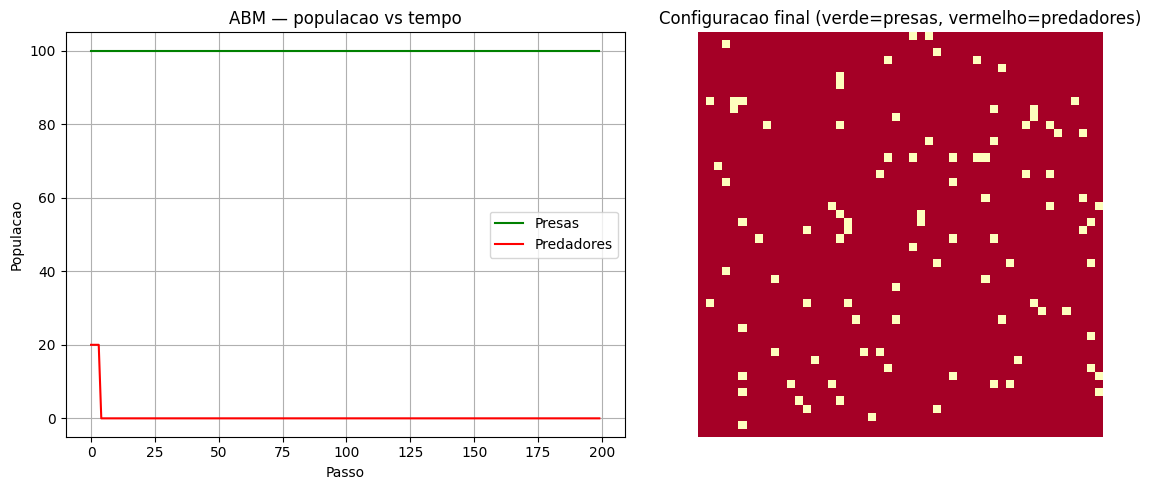

Figura salva como aula_06_exercicio_01_abm.png


In [17]:
# Versao alternativa da ABM (fallback) — corrigida
import random

TAM = 40
CLASS_NONE, CLASS_PREY, CLASS_PRED = 0, 1, 2

class Agente:
    def __init__(self, x, y, energia, tipo):
        self.x, self.y, self.energia, self.tipo = x, y, energia, tipo

def passo(agentes, grade, grama):
    # Regenerar grama (10% das celulas vazias)
    for x in range(TAM):
        for y in range(TAM):
            if grade[x][y] == CLASS_NONE and random.random() < 0.02:
                grama[x][y] = True

    random.shuffle(agentes)
    novos = []
    mortos = []
    for a in agentes:
        a.energia -= 1
        dx, dy = random.choice([(0,1),(0,-1),(1,0),(-1,0)])
        a.x = (a.x + dx) % TAM
        a.y = (a.y + dy) % TAM

        if a.tipo == CLASS_PREY:
            # Se tem grama, come e consome
            if grama[a.x][a.y]:
                a.energia += 3
                grama[a.x][a.y] = False
            # Reproducao se energia suficiente
            if a.energia > 8:
                for _ in range(6):
                    nx = (a.x + random.randint(-1, 1)) % TAM
                    ny = (a.y + random.randint(-1, 1)) % TAM
                    if grade[nx][ny] == CLASS_NONE:
                        novos.append(Agente(nx, ny, a.energia // 2, CLASS_PREY))
                        a.energia //= 2
                        break
        else:  # predador
            if grade[a.x][a.y] == CLASS_PREY:
                # Encontra e remove a presa desta celula
                for j, outra in enumerate(agentes):
                    if j != agentes.index(a) and outra.tipo == CLASS_PREY and outra.x == a.x and outra.y == a.y:
                        a.energia += 5
                        mortos.append(outra)
                        break
            # Reproducao se energia suficiente
            if a.energia > 12:
                for _ in range(6):
                    nx = (a.x + random.randint(-1, 1)) % TAM
                    ny = (a.y + random.randint(-1, 1)) % TAM
                    if grade[nx][ny] == CLASS_NONE:
                        novos.append(Agente(nx, ny, a.energia // 2, CLASS_PRED))
                        a.energia //= 2
                        break

    # Remove mortos (por fome ou por predacao)
    agentes = [a for a in agentes if a.energia > 0 and a not in mortos] + novos

    # Atualiza grade
    grade = [[CLASS_NONE] * TAM for _ in range(TAM)]
    for a in agentes:
        grade[a.x][a.y] = a.tipo
    return agentes, grade, grama

# Inicializacao
grade = [[CLASS_NONE] * TAM for _ in range(TAM)]
grama = [[True] * TAM for _ in range(TAM)]  # toda grade tem grama no inicio
agentes = []

for _ in range(200):
    x, y = random.randint(0, TAM - 1), random.randint(0, TAM - 1)
    a = Agente(x, y, 10, CLASS_PREY)
    agentes.append(a)
    grade[x][y] = CLASS_PREY

for _ in range(30):
    x, y = random.randint(0, TAM - 1), random.randint(0, TAM - 1)
    a = Agente(x, y, 8, CLASS_PRED)
    agentes.append(a)
    grade[x][y] = CLASS_PRED

# Simulacao
historico_presas, historico_preds, historico_grama = [], [], []
for t in range(300):
    agentes, grade, grama = passo(agentes, grade, grama)
    presas = sum(1 for a in agentes if a.tipo == CLASS_PREY)
    preds = sum(1 for a in agentes if a.tipo == CLASS_PRED)
    qtd_grama = sum(sum(1 for cel in row if cel) for row in grama)
    historico_presas.append(presas)
    historico_preds.append(preds)
    historico_grama.append(qtd_grama)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(historico_presas, color='green', label='Presas')
ax1.plot(historico_preds, color='red', label='Predadores')
ax1.plot(historico_grama, color='lightgreen', alpha=0.5, label='Celulas com grama')
ax1.set_xlabel('Passo')
ax1.set_ylabel('Populacao')
ax1.set_title('ABM — populacao vs tempo (com recurso limitado)')
ax1.legend()
ax1.grid(True)

grade_plot = [[0] * TAM for _ in range(TAM)]
for a in agentes:
    grade_plot[a.x][a.y] = 2 if a.tipo == CLASS_PRED else 1
ax2.imshow(grade_plot, cmap='RdYlGn', vmin=0, vmax=2, interpolation='nearest')
ax2.set_title('Configuracao final (verde=presas, vermelho=predadores)')
ax2.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(PASTA_AULA, 'aula_06_exercicio_01_abm.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figura salva como aula_06_exercicio_01_abm.png')


## 5. Pergunta

> **Comparando as duas abordagens (clássica EDO e ABM), quais as principais diferenças na forma de representar o mesmo sistema? O que cada abordagem permite enxergar que a outra não mostra?**


In [18]:
resposta_pergunta_1 = '''
Escreva sua resposta aqui.
'''


## 6. Gerar resposta com IA

Execute a célula abaixo para que a IA analise os resultados e gere uma resposta automaticamente.
Você pode editar o resultado depois se quiser.


In [19]:
from dotenv import load_dotenv
load_dotenv()
import os, json
from urllib.request import Request, urlopen

MODELO = os.getenv('OLLAMA_MODEL', 'ministral-3:3b')
BASE_URL = os.getenv('OLLAMA_BASE_URL', 'https://api.ollama.com').rstrip('/')
API_KEY = os.getenv('OLLAMA_API_KEY')

prompt = '''Voce e um assistente de um curso de sistemas de muitos agentes.
Responda em portugues, de forma clara e objetiva (maximo 4 paragrafos).

Pergunta: Comparando as duas abordagens (classica EDO e ABM) para modelar o sistema presa-predador,
quais as principais diferencas na forma de representar o mesmo sistema?
O que cada abordagem permite enxergar que a outra nao mostra?

Contexto:
- Abordagem classica (EDO): usa equacoes diferenciais ordinarias de Lotka-Volterra.
  Variaveis continuas (x, y representam densidades populacionais).
  Solucao deterministica e suave.
  Nao individualiza os agentes.
- Abordagem pela complexidade (ABM): cada animal e um agente individual numa grade 2D.
  Regras locais (movimento, reproducao, predacao).
  Comportamento emergente e estocastico.
  Permite visualizar a distribuicao espacial.'''

headers = {
    'Content-Type': 'application/json',
    'User-Agent': 'Mozilla/5.0',
    'Accept': 'application/json',
}
if API_KEY:
    headers['Authorization'] = f'Bearer {API_KEY}'

payload = {
    'model': MODELO,
    'messages': [{'role': 'user', 'content': prompt}],
    'stream': False,
    'options': {'temperature': 0.3, 'top_p': 0.9, 'num_predict': 800},
}

try:
    req = Request(BASE_URL + '/api/chat', data=json.dumps(payload).encode('utf-8'), headers=headers, method='POST')
    with urlopen(req, timeout=60) as resp:
        dados = json.loads(resp.read().decode('utf-8'))
    resposta = dados.get('message', {}).get('content', '').strip()
    if resposta:
        resposta_pergunta_1 = resposta
        print('Resposta gerada com sucesso!')
    else:
        print('IA retornou resposta vazia.')
except Exception as e:
    print(f'Erro ao consultar IA: {type(e).__name__}: {e}')

print()
print('Resposta atual:')
print(resposta_pergunta_1)


Resposta gerada com sucesso!

Resposta atual:
As **Equações Diferenciais Ordinárias (EDO)** e as **Agentes Baseadas em Modelos (ABM)** apresentam abordagens distintas para o sistema presa-predator, destacando-se na representação de dinâmicas e complexidade. Na EDO, o modelo é **determinístico e contínuo**, usando equações como as de Lotka-Volterra para descrever as densidades populacionais (*x* e *y*) como funções do tempo. Essa abordagem é ideal para analisar **comportamentos macroscópicos e tendências gerais**, como crescimento exponencial ou ciclos de população, sem precisar de detalhes individuais. No entanto, ela **ignora a estrutura espacial e o comportamento estocástico** dos agentes, limitando a representação de fenômenos como dispersão ou interações locais.

Já a **ABM** aproxima o sistema por meio de **agentes individuais** (presas e predadores) em uma grade 2D, onde cada agente segue regras de movimento, reprodução e predação de forma discreta e probabilística. Essa abordage

## 7. Exportar para o Moodle

Execute a célula abaixo para gerar o arquivo Markdown e o PDF.


In [20]:
import os
import shutil
import subprocess
from datetime import datetime

agora = datetime.now().strftime('%Y-%m-%d %H:%M')

PATH_MD = os.path.join(PASTA_AULA, 'aula_06_exercicio_01.md')
with open(PATH_MD, 'w', encoding='utf-8') as f:
    f.write('# Aula 06 — Exercicio 01: Classica vs Complexidade\n\n')
    f.write(f'_Executado em: {agora}_\n\n')
    f.write('---\n\n')
    f.write('## Abordagem classica (EDO)\n\n')
    f.write('![Modelo classico](aula_06_exercicio_01_classica.png)\n\n')
    f.write('---\n\n')
    f.write('## Abordagem pela complexidade (ABM)\n\n')
    f.write('![Modelo ABM](aula_06_exercicio_01_abm.png)\n\n')
    f.write('---\n\n')
    f.write('## Resposta do aluno\n\n')
    f.write(resposta_pergunta_1.strip())
    f.write('\n')

PATH_PDF = PATH_MD.replace('.md', '.pdf')
if shutil.which('pandoc'):
    subprocess.run(['pandoc', PATH_MD, '-o', PATH_PDF, '--pdf-engine=xelatex', '--resource-path', PASTA_AULA, '-V', 'mainfont=DejaVu Serif'], check=True)
else:
    print('Aviso: pandoc nao instalado. Execute ./setup.sh para instalar.')
print(f'Markdown: {os.path.abspath(PATH_MD)}')
print(f'PDF:      {os.path.abspath(PATH_PDF)}')


Markdown: /l/disk0/viniciusd/Projetos/simserv_jupyter_env/work/tarefas_moodle/tarefa_aula06/aula_06_exercicio_01.md
PDF:      /l/disk0/viniciusd/Projetos/simserv_jupyter_env/work/tarefas_moodle/tarefa_aula06/aula_06_exercicio_01.pdf
